In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv("CAISOHourlyLoadCSV.csv")





#data cleaning + preprocessing
# Validate expected columns
print("Columns:", df.columns.tolist())

# Rename the load column 
df = df.rename(columns={"CAISO Load (MW)": "Load_MW"})

# Parse Date column
df["Date"] = pd.to_datetime(df["Date"])

# Hour is "hour ending" 1..24 → convert to hour beginning 0..23
df["Hour_Begin"] = df["Hour"] - 1

# Build timestamp
df["Datetime"] = df["Date"] + pd.to_timedelta(df["Hour_Begin"], unit="h")

# Sort
df = df.sort_values("Datetime").reset_index(drop=True)

# Check duplicates 
dup = df.duplicated(subset=["Datetime"]).sum()
print("Duplicate timestamps:", dup)

# Average duplicates
df = df.groupby("Datetime", as_index=False)["Load_MW"].mean()

# Add time features for later
df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["Day"] = df["Datetime"].dt.day
df["DOW"] = df["Datetime"].dt.dayofweek  
df["Is_Weekend"] = (df["DOW"] >= 5).astype(int)

df.head()


Columns: ['Date', 'Hour', 'CAISO Load (MW)']
Duplicate timestamps: 1


,Datetime,Load_MW,Year,Month,Day,DOW,Is_Weekend
0,2024-11-01 00:00:00,22523.59,2024,11,1,4,0
1,2024-11-01 01:00:00,21909.62,2024,11,1,4,0
2,2024-11-01 02:00:00,21835.59,2024,11,1,4,0
3,2024-11-01 03:00:00,21205.08,2024,11,1,4,0
4,2024-11-01 04:00:00,21129.19,2024,11,1,4,0


In [29]:
## Monthly Peak Extraction
monthly_peak = (
    df.groupby(["Year", "Month"])["Load_MW"]
    .max()
    .reset_index()
    .rename(columns={"Load_MW": "MonthlyPeak_MW"})
)

monthly_peak


,Year,Month,MonthlyPeak_MW
0,2024,11,28434.06
1,2024,12,30265.19
2,2025,1,29173.90
3,2025,2,29126.53
4,2025,3,28127.03
5,2025,4,28444.29
6,2025,5,36265.24
7,2025,6,36284.07
8,2025,7,39655.38
9,2025,8,43922.82


In [31]:
## Question 1 Part a 
## March 2026 Peak Load Forecast (Part a)

# 1. Calculate Data-Driven Growth Rate (Nov 2024 to Oct 2025 trend)
monthly_avg = df.set_index('Datetime').resample('M')['Load_MW'].mean()
nov_24_avg = monthly_avg.iloc[0]
oct_25_avg = monthly_avg.iloc[-1]

# Annualize the growth observed in 11-month data span
growth_11_month = (oct_25_avg / nov_24_avg) - 1
data_driven_growth_rate = growth_11_month * (12 / 11)

# 2. Extract March 2025 Peak
march_2025_peak = df[(df['Datetime'].dt.year == 2025) & (df['Datetime'].dt.month == 3)]['Load_MW'].max()

# 3. Forecast March 2026
march_2026_peak_forecast = march_2025_peak * (1 + data_driven_growth_rate)
final_forecast = int(round(march_2026_peak_forecast))

# 4. Print Results
print(f"Calculated Annual Growth Rate: {round(data_driven_growth_rate * 100, 2)}%")
print(f"March 2025 Peak (Benchmark): {round(march_2025_peak, 2)} MW")
print("-" * 30)
print(f"March 2026 Peak Forecast (Point Forecast): {final_forecast} MW")



Calculated Annual Growth Rate: 4.6%
March 2025 Peak (Benchmark): 28127.03 MW
------------------------------
March 2026 Peak Forecast (Point Forecast): 29422 MW


C:\Users\Rimsha\AppData\Local\Temp\ipykernel_13640\1862641186.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df.set_index('Datetime').resample('M')['Load_MW'].mean()


In [32]:
#Part (b)
march_2025 = df[(df["Year"] == 2025) & (df["Month"] == 3)].copy()

peak_idx = march_2025["Load_MW"].idxmax()
peak_row = march_2025.loc[peak_idx]

print("March 2025 peak occurred on:", peak_row["Datetime"])
print("Day of week (0=Mon):", peak_row["Datetime"].dayofweek)


March 2025 peak occurred on: 2025-03-14 10:00:00
Day of week (0=Mon): 4


In [13]:
# Create all March 2026 dates
march_2026_dates = pd.date_range("2026-03-01", "2026-03-31", freq="D")

# March 2025 peak was on a Friday (dayofweek = 4)
fridays_2026 = [d for d in march_2026_dates if d.dayofweek == 4]

print("Fridays in March 2026:")
for d in fridays_2026:
    print(d.date())


Fridays in March 2026:
2026-03-06
2026-03-13
2026-03-20
2026-03-27


In [14]:
mid_month = pd.Timestamp("2026-03-15")

peak_date_2026 = min(fridays_2026, key=lambda x: abs(x - mid_month))

print("Forecasted March 2026 Peak Date:", peak_date_2026.date())


Forecasted March 2026 Peak Date: 2026-03-13


--- Persistence Baseline Performance ---
Mean Absolute Error (MAE): 2928.57 MW
Mean Absolute Percentage Error (MAPE): 8.43%
----------------------------------------


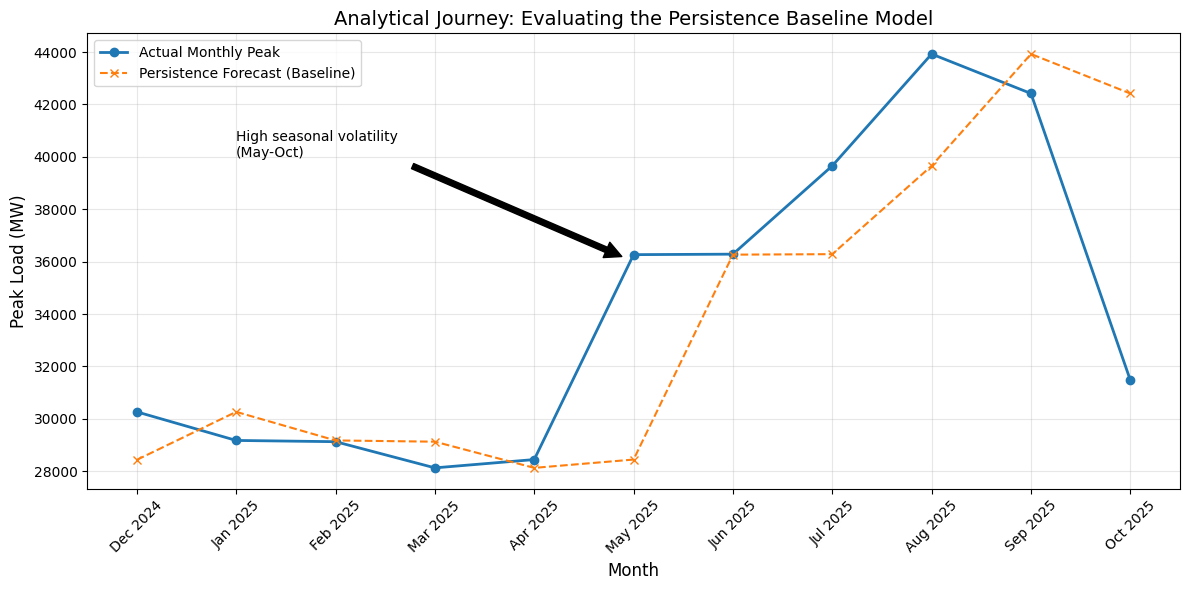

,Month_Label,Actual_Peak_MW,Forecast_Peak_MW,AE_MW,APE_Percent
1,Dec 2024,30265.19,28434.06,1831.13,6.050284
2,Jan 2025,29173.90,30265.19,1091.29,3.740638
3,Feb 2025,29126.53,29173.90,47.37,0.162635
4,Mar 2025,28127.03,29126.53,999.50,3.553521
5,Apr 2025,28444.29,28127.03,317.26,1.115373
6,May 2025,36265.24,28444.29,7820.95,21.565968
7,Jun 2025,36284.07,36265.24,18.83,0.051896
8,Jul 2025,39655.38,36284.07,3371.31,8.501520
9,Aug 2025,43922.82,39655.38,4267.44,9.715770
10,Sep 2025,42416.44,43922.82,1506.38,3.551406


In [35]:
import matplotlib.pyplot as plt
import numpy as np

## ---- 1. Data Preparation for Monthly Peaks ----
# Extract the monthly peak from the cleaned dataframe
monthly_peak = df.set_index('Datetime').resample('ME')['Load_MW'].max().reset_index()
monthly_peak.columns = ['Date', 'Actual_Peak_MW']

# Add Month/Year labels for plotting
monthly_peak['Month_Label'] = monthly_peak['Date'].dt.strftime('%b %Y')

## ---- 2. Persistence Model Backtest (Baseline) ----
# Forecast for Month (t) = Actual Peak of Month (t-1)
monthly_peak['Forecast_Peak_MW'] = monthly_peak['Actual_Peak_MW'].shift(1)

# Drop the first row (Nov 2024) because it has no "previous month" to forecast from
bt_results = monthly_peak.dropna().copy()

## ---- 3. Calculate Performance Metrics ----
bt_results['AE_MW'] = abs(bt_results['Actual_Peak_MW'] - bt_results['Forecast_Peak_MW'])
bt_results['APE_Percent'] = (bt_results['AE_MW'] / bt_results['Actual_Peak_MW']) * 100

mae = bt_results['AE_MW'].mean()
mape = bt_results['APE_Percent'].mean()

print(f"--- Persistence Baseline Performance ---")
print(f"Mean Absolute Error (MAE): {round(mae, 2)} MW")
print(f"Mean Absolute Percentage Error (MAPE): {round(mape, 2)}%")
print("-" * 40)

## ---- 4. Visualization: Actual vs. Forecast ----
plt.figure(figsize=(12, 6))
plt.plot(bt_results['Month_Label'], bt_results['Actual_Peak_MW'], 
         label='Actual Monthly Peak', marker='o', color='#1f77b4', linewidth=2)
plt.plot(bt_results['Month_Label'], bt_results['Forecast_Peak_MW'], 
         label='Persistence Forecast (Baseline)', linestyle='--', marker='x', color='#ff7f0e')

# Adding visual cues for the "Journey"
plt.title('Analytical Journey: Evaluating the Persistence Baseline Model', fontsize=14)
plt.ylabel('Peak Load (MW)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()

# Highlight the high error in Summer to justify why we switched methods
plt.annotate('High seasonal volatility\n(May-Oct)', xy=('May 2025', 36000), 
             xytext=('Jan 2025', 40000), arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.savefig('backtest_results.png') 
plt.show()

# Display the backtest table
display(bt_results[['Month_Label', 'Actual_Peak_MW', 'Forecast_Peak_MW', 'AE_MW', 'APE_Percent']])

Columns: ['Date', 'Hour', 'CAISO Load (MW)']
Duplicate timestamps: 1
Calculated Annual Growth Rate: 4.6%
March 2025 Peak (Benchmark): 28127.03 MW
------------------------------
March 2026 Peak Forecast (Point Forecast): 29422 MW
March 2025 peak occurred on: 2025-03-14 10:00:00
Day of week (0=Mon): 4
Fridays in March 2026:
2026-03-06
2026-03-13
2026-03-20
2026-03-27
Forecasted March 2026 Peak Date: 2026-03-13
--- Persistence Baseline Performance ---
Mean Absolute Error (MAE): 2928.57 MW
Mean Absolute Percentage Error (MAPE): 8.43%
----------------------------------------


C:\Users\Rimsha\AppData\Local\Temp\ipykernel_13640\1344577492.py:62: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df.set_index('Datetime').resample('M')['Load_MW'].mean()


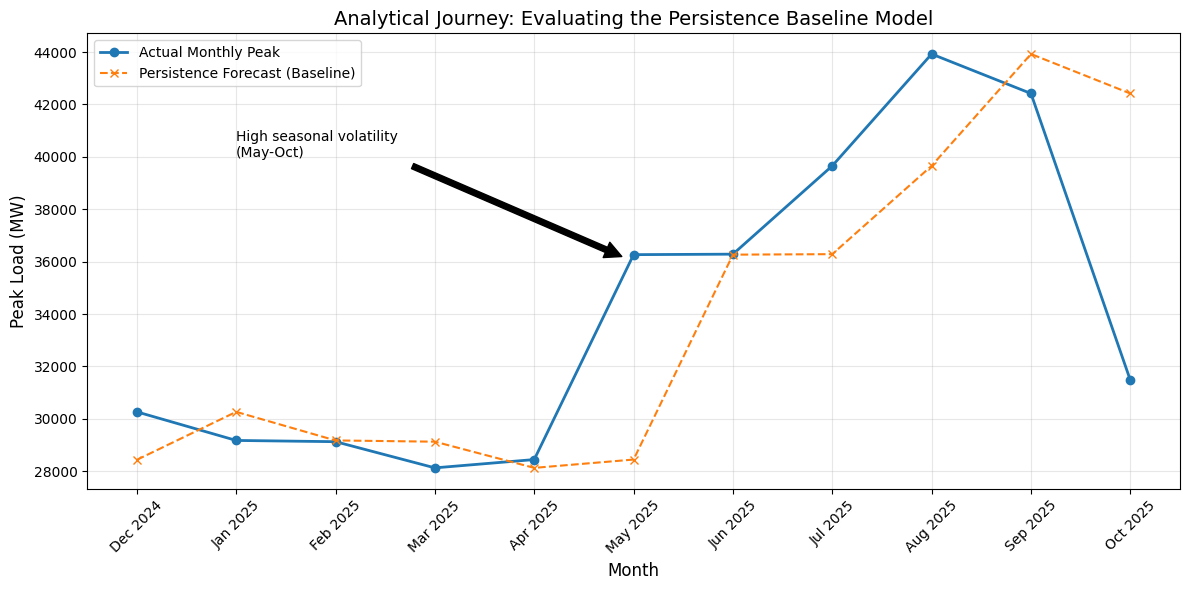

,Month_Label,Actual_Peak_MW,Forecast_Peak_MW,AE_MW,APE_Percent
1,Dec 2024,30265.19,28434.06,1831.13,6.050284
2,Jan 2025,29173.90,30265.19,1091.29,3.740638
3,Feb 2025,29126.53,29173.90,47.37,0.162635
4,Mar 2025,28127.03,29126.53,999.50,3.553521
5,Apr 2025,28444.29,28127.03,317.26,1.115373
6,May 2025,36265.24,28444.29,7820.95,21.565968
7,Jun 2025,36284.07,36265.24,18.83,0.051896
8,Jul 2025,39655.38,36284.07,3371.31,8.501520
9,Aug 2025,43922.82,39655.38,4267.44,9.715770
10,Sep 2025,42416.44,43922.82,1506.38,3.551406


In [45]:
#part d 
#Data Preprocessing/ cleaning 
import pandas as pd
import numpy as np

df = pd.read_csv("CAISOHourlyLoadCSV.csv")





#data cleaning + preprocessing
# Validate expected columns
print("Columns:", df.columns.tolist())

# Rename the load column 
df = df.rename(columns={"CAISO Load (MW)": "Load_MW"})

# Parse Date column
df["Date"] = pd.to_datetime(df["Date"])

# Hour is "hour ending" 1..24 → convert to hour beginning 0..23
df["Hour_Begin"] = df["Hour"] - 1

# Build timestamp
df["Datetime"] = df["Date"] + pd.to_timedelta(df["Hour_Begin"], unit="h")

# Sort
df = df.sort_values("Datetime").reset_index(drop=True)

# Check duplicates 
dup = df.duplicated(subset=["Datetime"]).sum()
print("Duplicate timestamps:", dup)

# Average duplicates
df = df.groupby("Datetime", as_index=False)["Load_MW"].mean()

# Add time features for later
df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["Day"] = df["Datetime"].dt.day
df["DOW"] = df["Datetime"].dt.dayofweek  
df["Is_Weekend"] = (df["DOW"] >= 5).astype(int)

df.head()

## Monthly Peak Extraction
monthly_peak = (
    df.groupby(["Year", "Month"])["Load_MW"]
    .max()
    .reset_index()
    .rename(columns={"Load_MW": "MonthlyPeak_MW"})
)

monthly_peak


## Question 1 Part a 
## March 2026 Peak Load Forecast (Part a)

# 1. Calculate Data-Driven Growth Rate (Nov 2024 to Oct 2025 trend)
monthly_avg = df.set_index('Datetime').resample('M')['Load_MW'].mean()
nov_24_avg = monthly_avg.iloc[0]
oct_25_avg = monthly_avg.iloc[-1]

# Annualize the growth observed in 11-month data span
growth_11_month = (oct_25_avg / nov_24_avg) - 1
data_driven_growth_rate = growth_11_month * (12 / 11)

# 2. Extract March 2025 Peak
march_2025_peak = df[(df['Datetime'].dt.year == 2025) & (df['Datetime'].dt.month == 3)]['Load_MW'].max()

# 3. Forecast March 2026
march_2026_peak_forecast = march_2025_peak * (1 + data_driven_growth_rate)
final_forecast = int(round(march_2026_peak_forecast))

# 4. Print Results
print(f"Calculated Annual Growth Rate: {round(data_driven_growth_rate * 100, 2)}%")
print(f"March 2025 Peak (Benchmark): {round(march_2025_peak, 2)} MW")
print("-" * 30)
print(f"March 2026 Peak Forecast (Point Forecast): {final_forecast} MW")


#Part (b)
march_2025 = df[(df["Year"] == 2025) & (df["Month"] == 3)].copy()

peak_idx = march_2025["Load_MW"].idxmax()
peak_row = march_2025.loc[peak_idx]

print("March 2025 peak occurred on:", peak_row["Datetime"])
print("Day of week (0=Mon):", peak_row["Datetime"].dayofweek)


# Create all March 2026 dates
march_2026_dates = pd.date_range("2026-03-01", "2026-03-31", freq="D")

# March 2025 peak was on a Friday (dayofweek = 4)
fridays_2026 = [d for d in march_2026_dates if d.dayofweek == 4]

print("Fridays in March 2026:")
for d in fridays_2026:
    print(d.date())


mid_month = pd.Timestamp("2026-03-15")

peak_date_2026 = min(fridays_2026, key=lambda x: abs(x - mid_month))

print("Forecasted March 2026 Peak Date:", peak_date_2026.date())

import matplotlib.pyplot as plt
import numpy as np

## ---- 1. Data Preparation for Monthly Peaks ----
# Extract the monthly peak from the cleaned dataframe
monthly_peak = df.set_index('Datetime').resample('ME')['Load_MW'].max().reset_index()
monthly_peak.columns = ['Date', 'Actual_Peak_MW']

# Add Month/Year labels for plotting
monthly_peak['Month_Label'] = monthly_peak['Date'].dt.strftime('%b %Y')

## ---- 2. Persistence Model Backtest (Baseline) ----
# Forecast for Month (t) = Actual Peak of Month (t-1)
monthly_peak['Forecast_Peak_MW'] = monthly_peak['Actual_Peak_MW'].shift(1)

# Drop the first row (Nov 2024) because it has no "previous month" to forecast from
bt_results = monthly_peak.dropna().copy()

## ---- 3. Calculate Performance Metrics ----
bt_results['AE_MW'] = abs(bt_results['Actual_Peak_MW'] - bt_results['Forecast_Peak_MW'])
bt_results['APE_Percent'] = (bt_results['AE_MW'] / bt_results['Actual_Peak_MW']) * 100

mae = bt_results['AE_MW'].mean()
mape = bt_results['APE_Percent'].mean()

print(f"--- Persistence Baseline Performance ---")
print(f"Mean Absolute Error (MAE): {round(mae, 2)} MW")
print(f"Mean Absolute Percentage Error (MAPE): {round(mape, 2)}%")
print("-" * 40)

## ---- 4. Visualization: Actual vs. Forecast ----
plt.figure(figsize=(12, 6))
plt.plot(bt_results['Month_Label'], bt_results['Actual_Peak_MW'], 
         label='Actual Monthly Peak', marker='o', color='#1f77b4', linewidth=2)
plt.plot(bt_results['Month_Label'], bt_results['Forecast_Peak_MW'], 
         label='Persistence Forecast (Baseline)', linestyle='--', marker='x', color='#ff7f0e')

# Adding visual cues for the "Journey"
plt.title('Analytical Journey: Evaluating the Persistence Baseline Model', fontsize=14)
plt.ylabel('Peak Load (MW)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()

# Highlight the high error in Summer to justify why we switched methods
plt.annotate('High seasonal volatility\n(May-Oct)', xy=('May 2025', 36000), 
             xytext=('Jan 2025', 40000), arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.savefig('backtest_results.png') 
plt.show()

# Display the backtest table
display(bt_results[['Month_Label', 'Actual_Peak_MW', 'Forecast_Peak_MW', 'AE_MW', 'APE_Percent']])




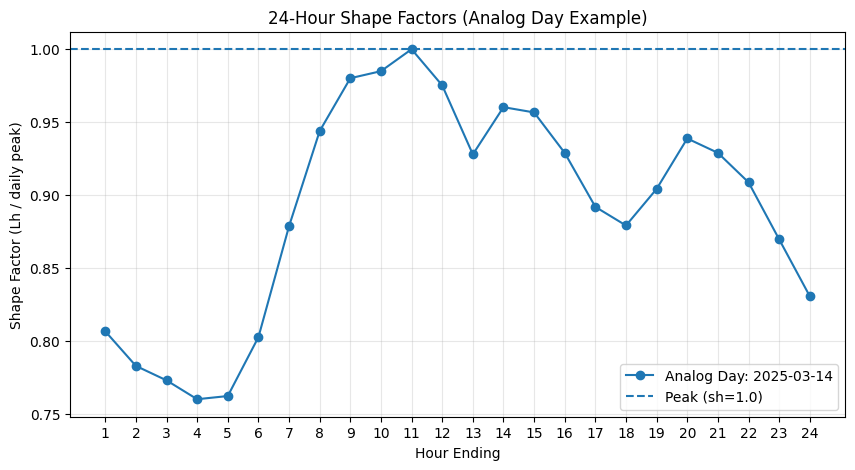

In [21]:
#3a
import matplotlib.pyplot as plt
import pandas as pd

# Ensure we have DateOnly and Hour_Ending
tmp = df.copy()
tmp["DateOnly"] = tmp["Datetime"].dt.floor("D")
tmp["Hour_Ending"] = tmp["Datetime"].dt.hour + 1  # 1..24

# Example analog day (March 14, 2025)
analog_date = pd.Timestamp("2025-03-14")
analog_day = tmp[tmp["DateOnly"] == analog_date].sort_values("Hour_Ending").copy()

L_star_2025 = analog_day["Load_MW"].max()
analog_day["Shape_Factor"] = analog_day["Load_MW"] / L_star_2025

plt.figure(figsize=(10, 5))
plt.plot(analog_day["Hour_Ending"], analog_day["Shape_Factor"], marker='o', label="Analog Day: 2025-03-14")
plt.axhline(1.0, linestyle='--', label="Peak (sh=1.0)")

plt.title("24-Hour Shape Factors (Analog Day Example)")
plt.xlabel("Hour Ending")
plt.ylabel("Shape Factor (Lh / daily peak)")
plt.xticks(range(1, 25))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [22]:
#3c 
import pandas as pd
import numpy as np

DATA_PATH = "CAISOHourlyLoadCSV.csv"

# Your Task 1 outputs:
L_star = 28550                      # Task 1a
d_star = pd.Timestamp("2026-03-13") # Task 1b (not used directly in data; for labeling)

# Choose analog day from dataset (March 2025 peak day):
analog_date = pd.Timestamp("2025-03-14")

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])

# Extract analog day hourly profile
analog = df[df["Date"] == analog_date].copy()
analog = analog.sort_values("Hour")  # Hour is Hour Ending (1..24)

# Daily peak on analog day
analog_peak = analog["CAISO Load (MW)"].max()
peak_hour = int(analog.loc[analog["CAISO Load (MW)"].idxmax(), "Hour"])

# Shape factors (normalized by analog day's peak)
analog["sh"] = analog["CAISO Load (MW)"] / analog_peak

# Enforce exact internal consistency (optional, numerical safety)
analog["sh"] = analog["sh"] / analog["sh"].max()

# Implied hourly forecast MW on d* using L*
analog["Lh_forecast_MW"] = analog["sh"] * L_star

print("Analog day:", analog_date.date(), "| Analog peak MW:", round(analog_peak,2), "| Peak hour (HE):", peak_hour)
print("Forecast day (d*):", d_star.date(), "| L*:", L_star, "MW")
print("Max shape factor:", round(analog["sh"].max(), 6))

shape_factors = analog[["Hour", "sh"]].copy()
shape_factors["sh"] = shape_factors["sh"].round(4)

shape_factors


Analog day: 2025-03-14 | Analog peak MW: 28127.03 | Peak hour (HE): 11
Forecast day (d*): 2026-03-13 | L*: 28550 MW
Max shape factor: 1.0


,Hour,sh
3192,1,0.8067
3193,2,0.7830
3194,3,0.7731
3195,4,0.7602
3196,5,0.7624
3197,6,0.8027
3198,7,0.8787
3199,8,0.9439
3200,9,0.9801
3201,10,0.9850


In [52]:
import pandas as pd
import numpy as np


DATA_PATH = "CAISOHourlyLoadCSV.csv"

DATE_COL = "Date"               
HOUR_COL = "Hour"                
LOAD_COL = "CAISO Load (MW)"     

# Forecast inputs from Task 1
L_star = 28550.0                 
d_star = "2026-03-13"            

# Analog day used for Task 3(c) (observed March 2025 peak day)
analog_date = "2025-03-14"     


# LOAD AND BASIC CLEANING


df = pd.read_csv(DATA_PATH)

print("Original columns:", list(df.columns))

# Keep only relevant columns and standardize names
df = df[[DATE_COL, HOUR_COL, LOAD_COL]].copy()
df.rename(columns={
    DATE_COL: "Date",
    HOUR_COL: "HE",
    LOAD_COL: "Load_MW"
}, inplace=True)

# Parse Date and make sure types are right
df["Date"] = pd.to_datetime(df["Date"]).dt.date

# Make sure HE is an integer (Hour Ending)
df["HE"] = df["HE"].astype(int)

print("\nHead of processed data:")
print(df.head())


# HELPER: COMPUTE SHAPE FACTORS FOR A GIVEN DATE


def compute_shape_factors_for_date(data: pd.DataFrame, date_str: str):
    """
    Compute sh_h = L_h / max(L_h) for the given date.
    data: DataFrame with columns ['Date', 'HE', 'Load_MW']
    date_str: 'YYYY-MM-DD'
    returns: (day_df, daily_peak)
    """
    target_date = pd.to_datetime(date_str).date()
    day_df = data[data["Date"] == target_date].copy()

    if day_df.empty:
        raise ValueError(f"No data found for date {date_str}")

    # Optional check: ideally 24 hours
    if day_df["HE"].nunique() != 24:
        print(f"Warning: {date_str} has {day_df['HE'].nunique()} unique HE values.")

    # Sort by hour
    day_df = day_df.sort_values("HE")

    # Daily peak load
    daily_peak = day_df["Load_MW"].max()

    # Shape factors
    day_df["sh_h"] = day_df["Load_MW"] / daily_peak

    print(f"\nAnalog date {date_str}:")
    print(f"  Daily peak load = {daily_peak:.2f} MW")
    print(f"  Max shape factor = {day_df['sh_h'].max():.4f}")

    return day_df, daily_peak


# TASK 3(c): USE ANALOG DAY TO FORECAST 24 SHAPE FACTORS


analog_df, analog_peak = compute_shape_factors_for_date(df, analog_date)

# 24-hour normalized shape for our chosen March peak-like day
shape_factors = analog_df[["HE", "sh_h"]].copy()

# Internal consistency check: max sh_h must be 1.0
print("\nInternal consistency check:")
print("  max(sh_h) =", shape_factors["sh_h"].max())


# IMPLIED HOURLY LOAD FORECAST FOR d*
# L_hat_h = sh_h * L*


shape_factors["L_hat_h"] = shape_factors["sh_h"] * L_star
shape_factors["Date_forecast"] = pd.to_datetime(d_star).date()

# Reorder columns nicely
shape_table = shape_factors[["Date_forecast", "HE", "sh_h", "L_hat_h"]].copy()
shape_table.rename(columns={
    "Date_forecast": "Date",
    "HE": "HourEnding",
    "sh_h": "ShapeFactor",
    "L_hat_h": "Forecast_Load_MW"
}, inplace=True)

# Print table 
print("\nForecasted 24 Shape Factors for d* = {}:".format(d_star))
print(
    shape_table.to_string(
        index=False,
        formatters={
            "ShapeFactor":      lambda x: f"{x:.4f}",
            "Forecast_Load_MW": lambda x: f"{x:,.2f}"
        }
    )
)



output_file = "Q3c_ShapeFactors_dstar.csv"
shape_table.to_csv(output_file, index=False)
print(f"\nSaved shape factors to '{output_file}'.")


Original columns: ['Date', 'Hour', 'CAISO Load (MW)']

Head of processed data:
         Date  HE   Load_MW
0  2024-11-01   1  22523.59
1  2024-11-01   2  21909.62
2  2024-11-01   3  21835.59
3  2024-11-01   4  21205.08
4  2024-11-01   5  21129.19

Analog date 2025-03-14:
  Daily peak load = 28127.03 MW
  Max shape factor = 1.0000

Internal consistency check:
  max(sh_h) = 1.0

Forecasted 24 Shape Factors for d* = 2026-03-13:
      Date  HourEnding ShapeFactor Forecast_Load_MW
2026-03-13           1      0.8067        23,032.18
2026-03-13           2      0.7830        22,355.02
2026-03-13           3      0.7731        22,072.32
2026-03-13           4      0.7602        21,703.31
2026-03-13           5      0.7624        21,765.62
2026-03-13           6      0.8027        22,917.01
2026-03-13           7      0.8787        25,088.01
2026-03-13           8      0.9439        26,949.37
2026-03-13           9      0.9801        27,983.03
2026-03-13          10      0.9850        28,120.73

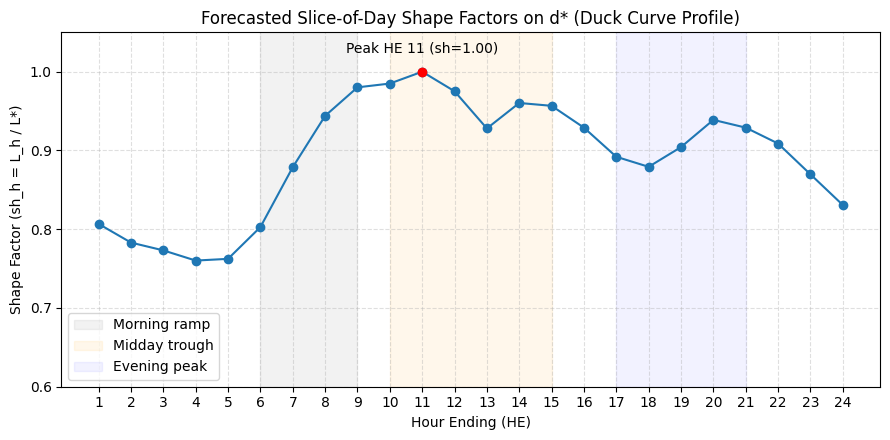

In [53]:
import numpy as np
import matplotlib.pyplot as plt

hours = shape_factors["HE"].values
sh = shape_factors["sh_h"].values

plt.figure(figsize=(9, 4.5))
plt.plot(hours, sh, marker="o")

# Highlight morning / midday / evening regions roughly
plt.axvspan(6, 9,  color="grey",   alpha=0.1, label="Morning ramp")
plt.axvspan(10,15, color="orange", alpha=0.08, label="Midday trough")
plt.axvspan(17,21, color="blue",   alpha=0.05, label="Evening peak")

# ---------- Mark the max hour explicitly (fixed) ----------
peak_idx = np.argmax(sh)        # positional index 0..23
peak_hour = hours[peak_idx]     # hour at that position
peak_val = sh[peak_idx]         # shape factor at that position

plt.scatter([peak_hour], [peak_val], color="red", zorder=5)
plt.text(peak_hour, peak_val + 0.02,
         f"Peak HE {int(peak_hour)} (sh=1.00)",
         ha="center", va="bottom")

plt.title("Forecasted Slice-of-Day Shape Factors on d* (Duck Curve Profile)")
plt.xlabel("Hour Ending (HE)")
plt.ylabel("Shape Factor (sh_h = L_h / L*)")
plt.xticks(range(1, 25))
plt.ylim(0.6, 1.05)   
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="lower left", frameon=True)

plt.tight_layout()
plt.show()
